<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Coffee_shop_revenue_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Coffee Shop Daily Revenue Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("coffee_shop_revenue.csv")

In [ ]:
df.shape

(2000, 7)

In [ ]:
df.head(10)

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
5,121,8.88,6,9,183.49,484,1155.18
6,238,9.00,11,4,331.35,156,2179.13
7,70,7.81,10,3,273.27,237,890.17
8,152,8.78,14,2,341.79,825,1704.94
9,171,7.73,7,5,344.51,135,2025.55


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [ ]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


* Looking at the dataset we conclude that there is no missing values in dataset accross the columns.
* Also there is all numerical features and no catogorical feature present in dataset so that no need for encoding.


**Plotting Histogram for visualize distribution of Features**

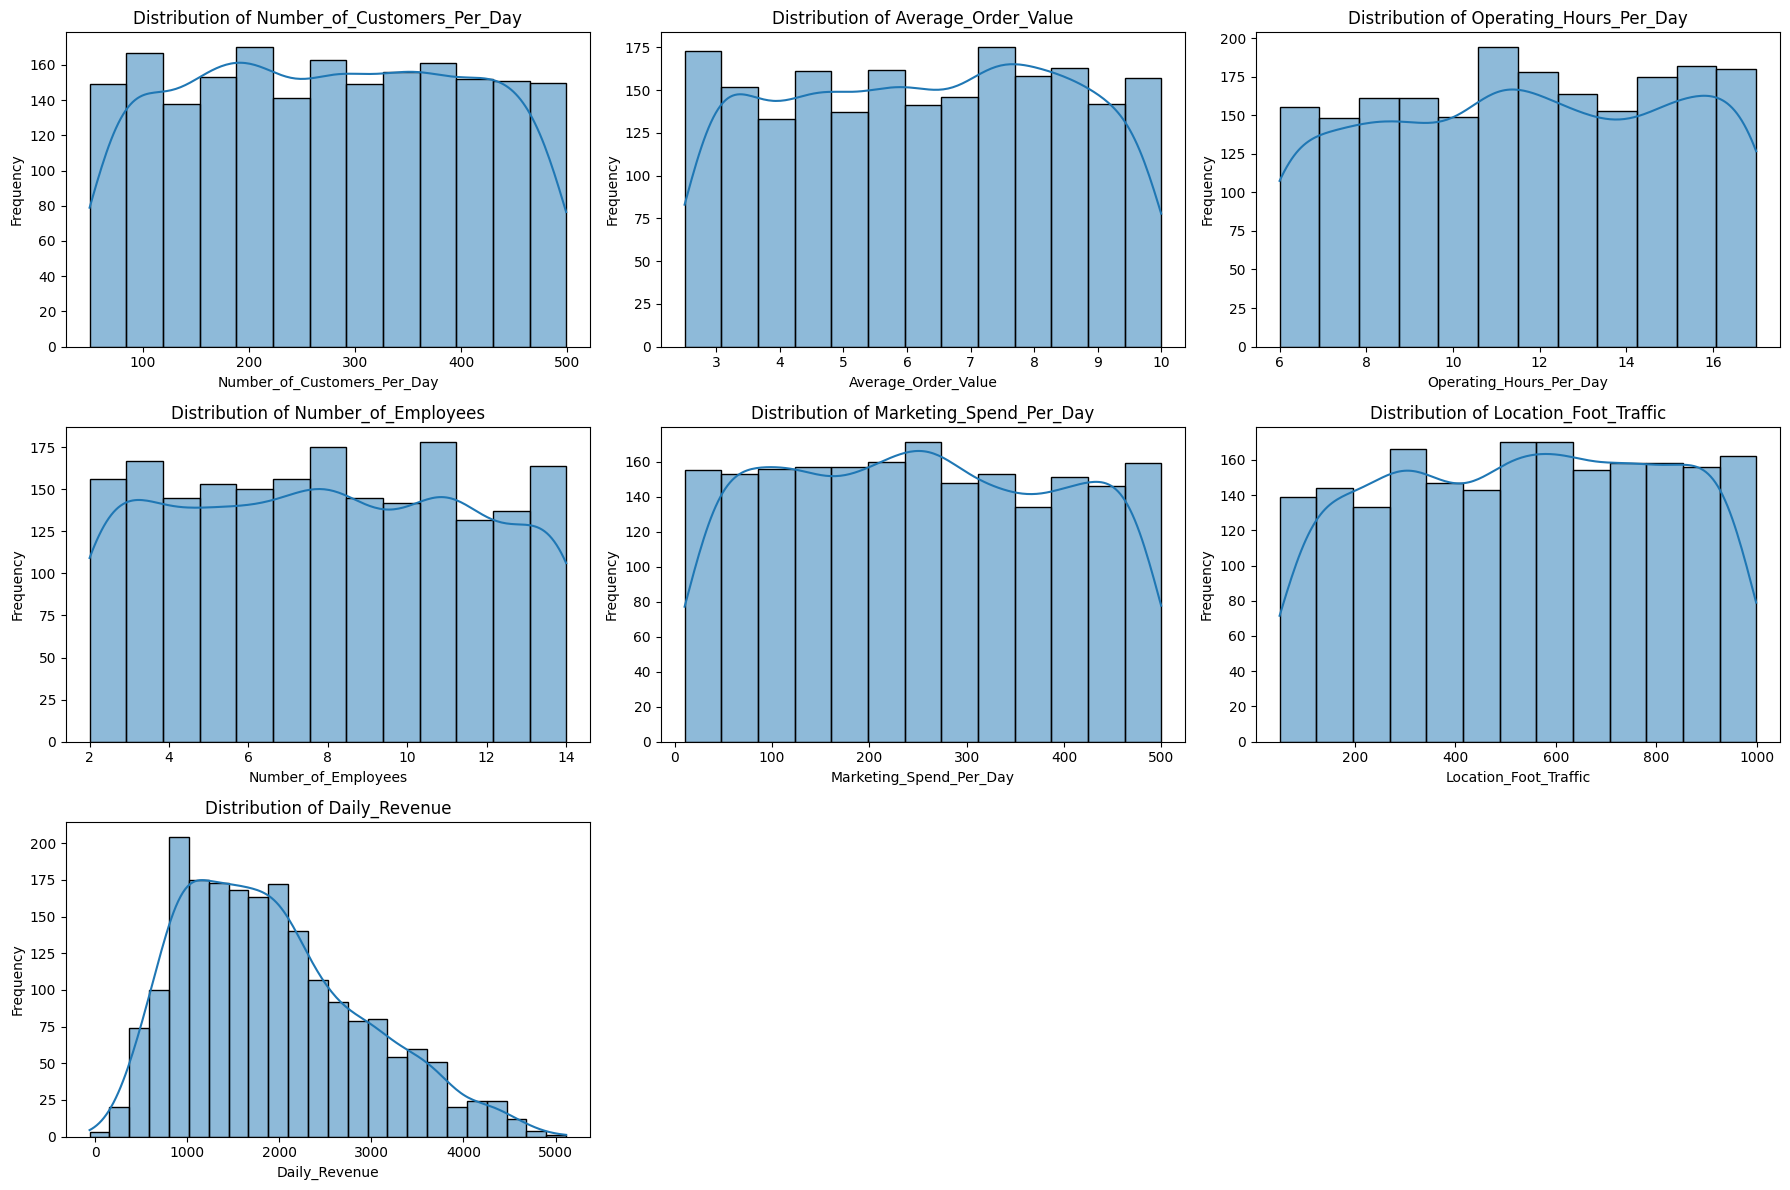

In [ ]:
   fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* The histograms show the distribution of each feature in your dataset.
* Most features likely appear to have relatively uniform distributions, meaning values are spread fairly evenly across their ranges.
* However, 'Daily_Revenue' shows a right-skewed distribution, indicating that the majority of daily revenues are concentrated at the lower end, with fewer instances of very high revenues.

**Detecting Outliers**

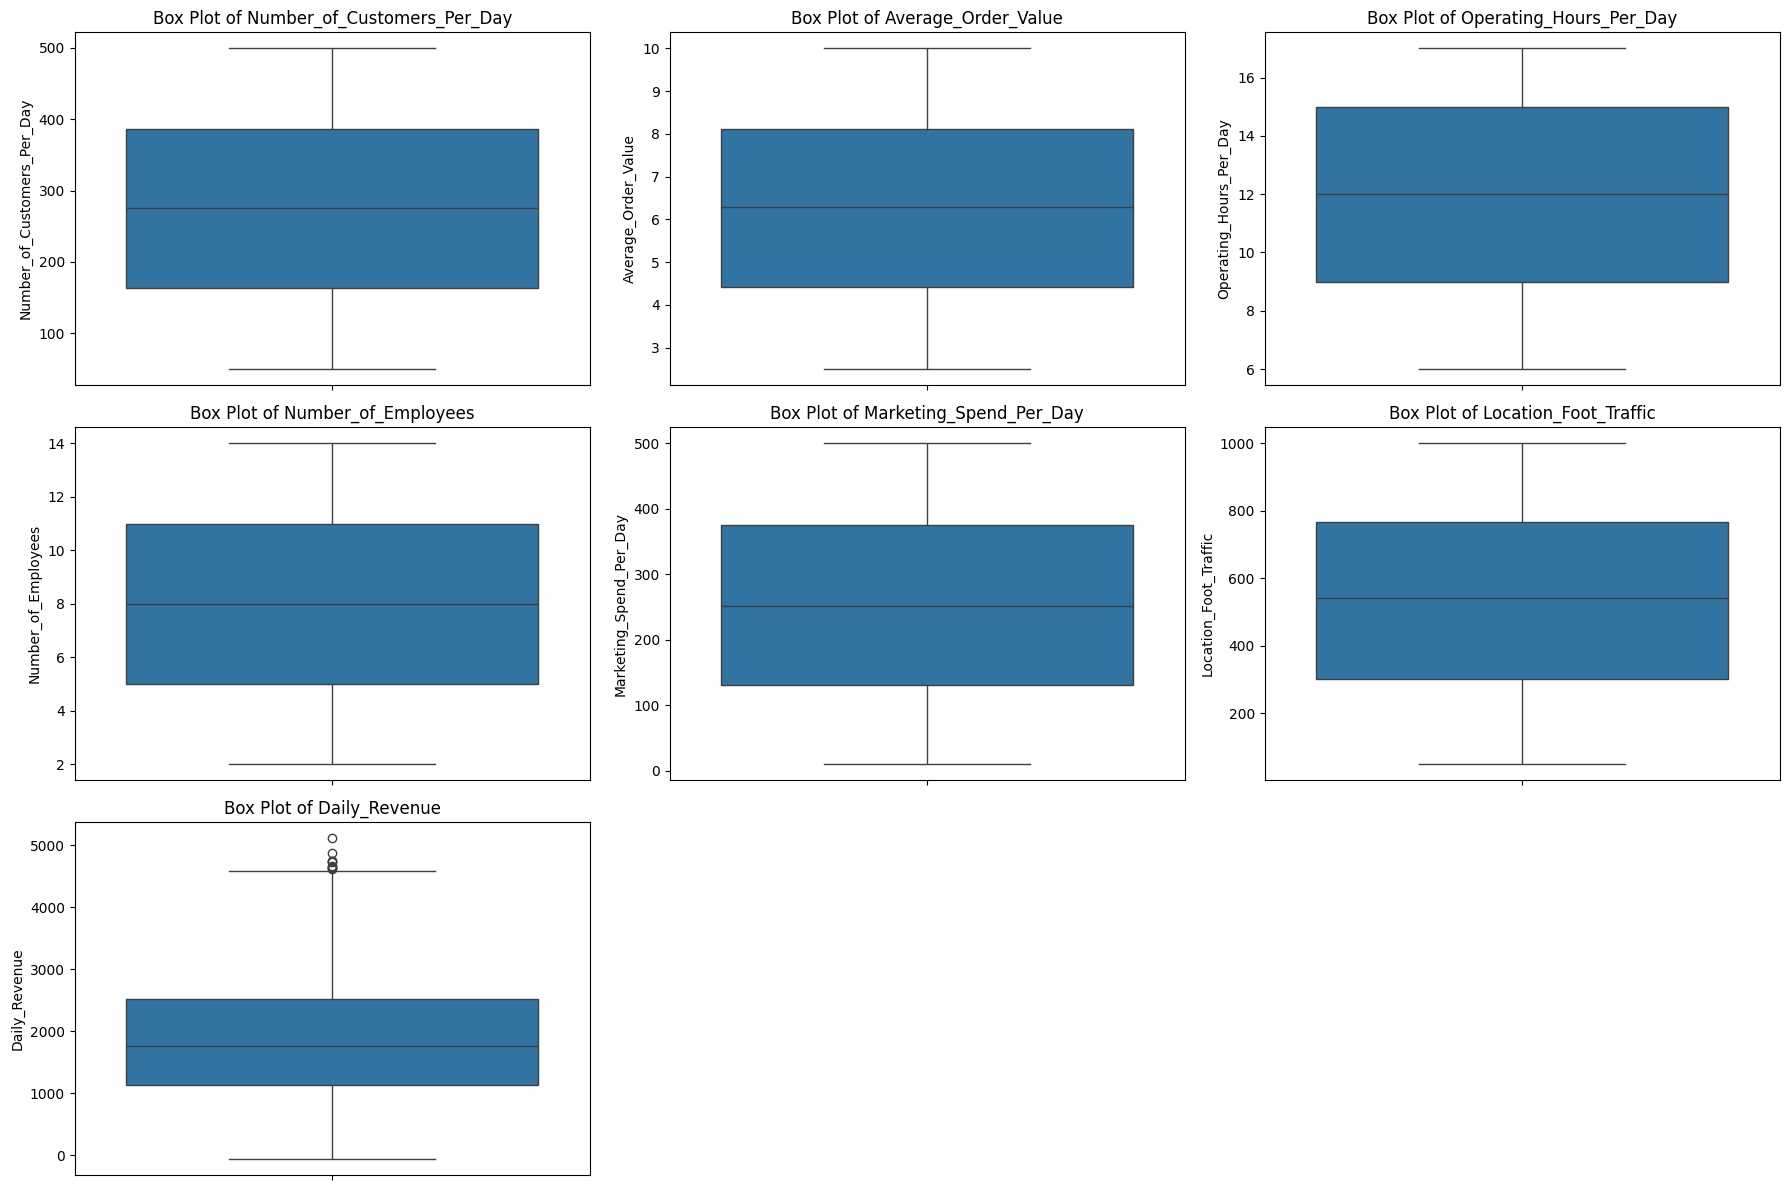

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Box plot indicates that there is no outliers are detected in most of the feature.
* However, daily revenue feature have some outliers but it is not looks like data entry error but it can be have revenue on some business days or Holidays.

**Finding relation across the features**

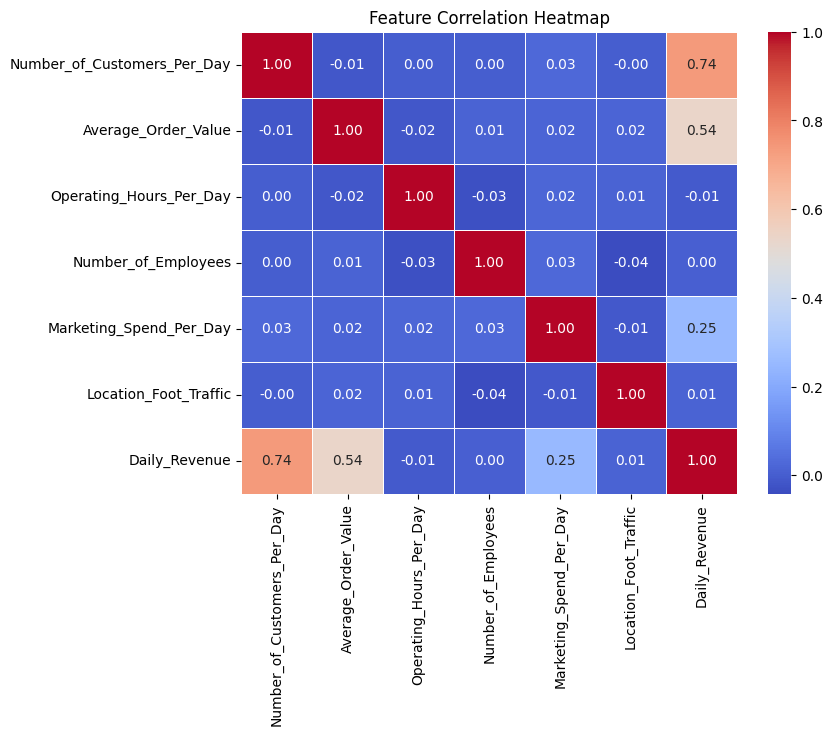

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

 **Key Drivers of Daily_Revenue (Target Variable)**

 * Number_of_Customers_Per_Day ($r = 0.74$): Strong Positive CorrelationThis is the strongest predictor of daily revenue. Increasing actual foot traffic inside the shop directly translates to higher revenue.
 * Average_Order_Value ($r = 0.54$): Moderate-to-Strong Positive CorrelationThe second most influential factor. Encouraging customers to spend more per transaction (up-selling/cross-selling) significantly boosts revenue.

 * Marketing_Spend_Per_Day ($r = 0.25$): Weak Positive CorrelationMarketing spend has a slight positive impact on revenue, but it is far less decisive than actual customer volume or order size.

 * Variables with Zero Impact on RevenueOperating_Hours_Per_Day ($r = -0.01$)Number_of_Employees ($r = 0.00$)Location_Foot_Traffic ($r = 0.01$)
 * Also there is no Multicoliniarity detected among the features.

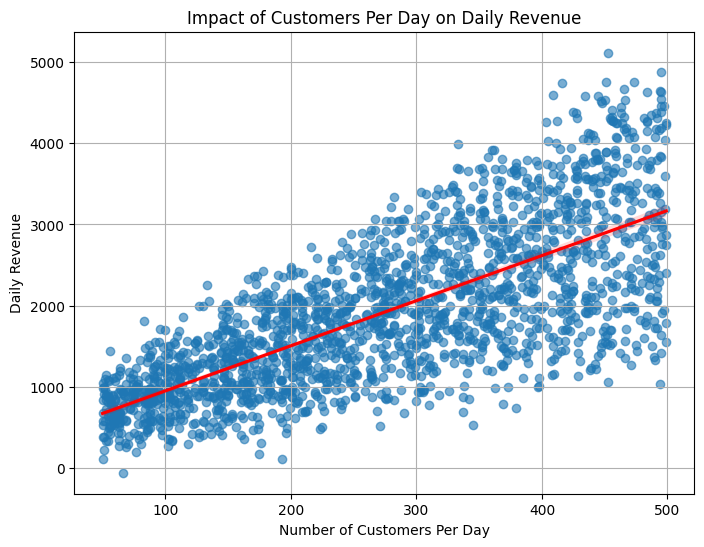

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(x=df["Number_of_Customers_Per_Day"], y=df["Daily_Revenue"], scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.xlabel("Number of Customers Per Day")
plt.ylabel("Daily Revenue")
plt.title("Impact of Customers Per Day on Daily Revenue")
plt.grid(True)
plt.show()

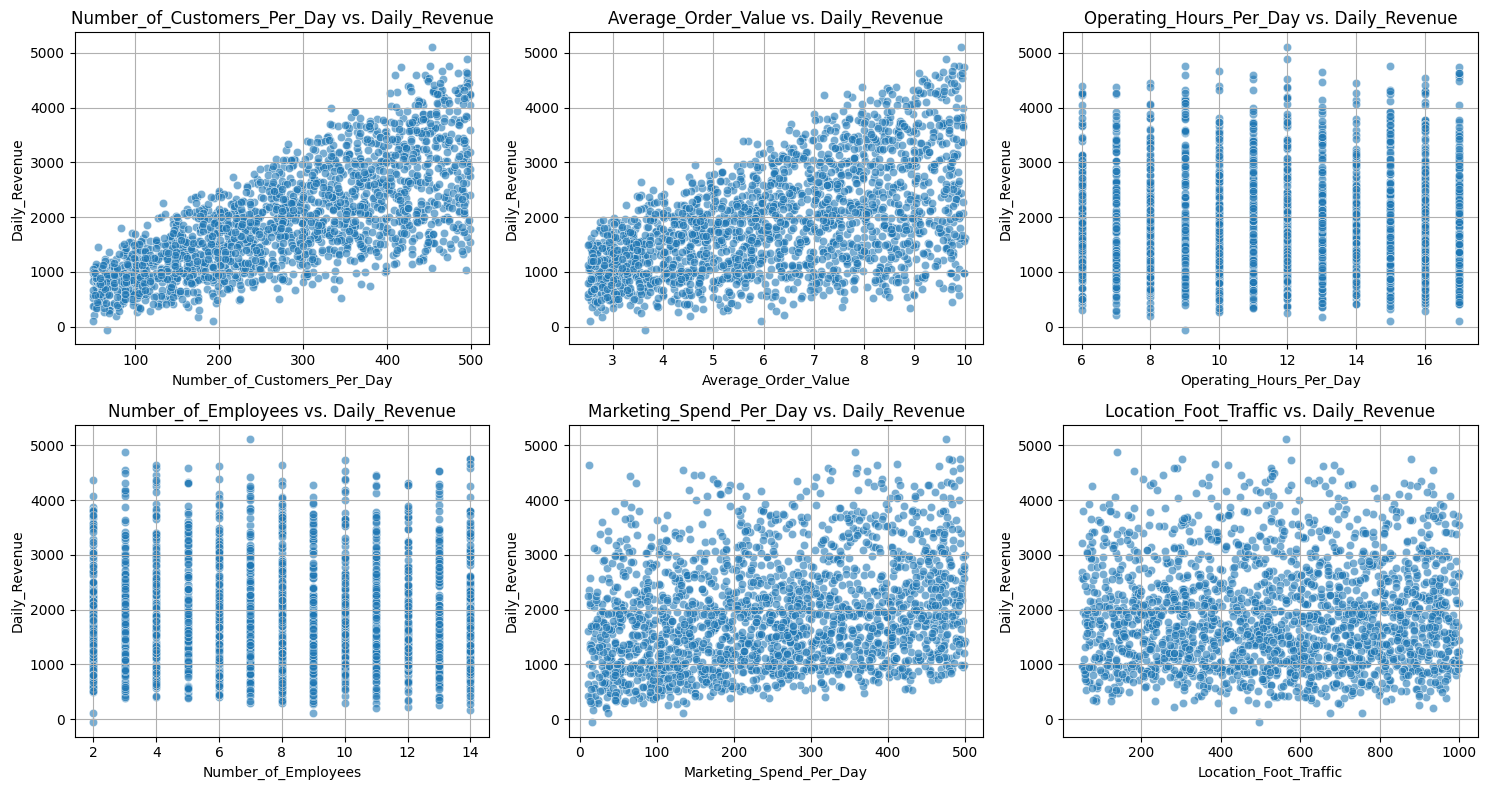

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from X_data
feature_names = X.columns

# Determine the number of rows and columns for subplots
num_features = len(feature_names)
num_cols = 3  # You can adjust this for desired layout
num_rows = (num_features + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(feature_names):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=X[feature], y=y, alpha=0.6)
    plt.title(f'{feature} vs. Daily_Revenue')
    plt.xlabel(feature)
    plt.ylabel('Daily_Revenue')
    plt.grid(True)

plt.tight_layout()
plt.show()

#Simple Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('Daily_Revenue', axis=1)
y = df['Daily_Revenue']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 97569.72
Root Mean Squared Error (RMSE): 312.36
R-squared (R2): 0.90


## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model
# You might want to tune the 'alpha' parameter for optimal performance
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the Lasso model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regression Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"Lasso Regression R-squared (R2): {r2_lasso:.2f}")

Lasso Regression Mean Squared Error (MSE): 97567.83
Lasso Regression Root Mean Squared Error (RMSE): 312.36
Lasso Regression R-squared (R2): 0.90


## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
# You might want to tune the 'alpha' parameter for optimal performance
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the Ridge model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regression Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"Ridge Regression R-squared (R2): {r2_ridge:.2f}")

Ridge Regression Mean Squared Error (MSE): 97566.72
Ridge Regression Root Mean Squared Error (RMSE): 312.36
Ridge Regression R-squared (R2): 0.90


* It appears that both Lasso and Ridge regression models yielded very similar performance metrics to the standard Linear Regression model, with R-squared values of 0.90 and comparable MSE/RMSE.
* This suggests that for this particular dataset and current alpha values, the regularization applied by Lasso and Ridge did not significantly change the model's predictive power compared to ordinary least squares.
* Since there is no multicoliniarity in features both regularization techniques does not affect the model performance.


### Predicted vs. Actual Values for Linear Regression

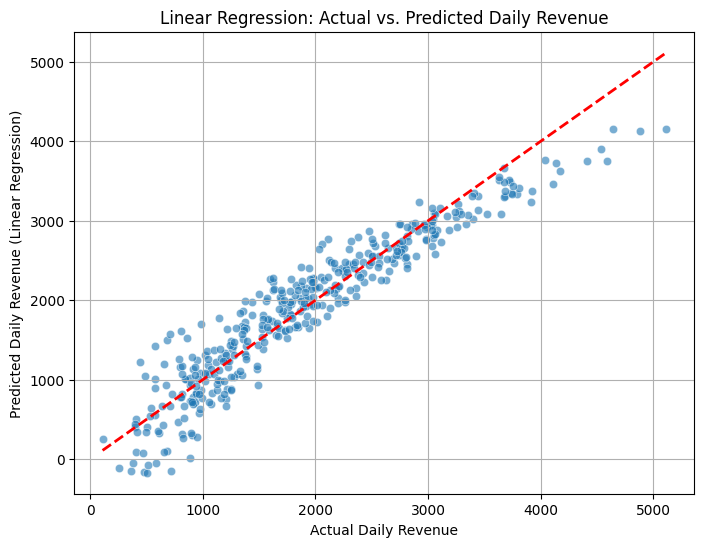

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Daily Revenue")
plt.ylabel("Predicted Daily Revenue (Linear Regression)")
plt.title("Linear Regression: Actual vs. Predicted Daily Revenue")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X_data = df.drop('Daily_Revenue', axis=1)
y_data = df['Daily_Revenue']

# Split the data into training and testing sets (re-split as the original X_train/X_test were not scaled)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler on the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Random Forest Regressor with Scaled Data

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model with scaled data
# You might want to tune parameters like n_estimators, max_depth, etc.
rf_model_scaled = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_rf_scaled = rf_model_scaled.predict(X_test_scaled)

# Evaluate the Random Forest model
mse_rf_scaled = mean_squared_error(y_test, y_pred_rf_scaled)
rmse_rf_scaled = np.sqrt(mse_rf_scaled)
r2_rf_scaled = r2_score(y_test, y_pred_rf_scaled)

print(f"Scaled Random Forest Regressor Mean Squared Error (MSE): {mse_rf_scaled:.2f}")
print(f"Scaled Random Forest Regressor Root Mean Squared Error (RMSE): {rmse_rf_scaled:.2f}")
print(f"Scaled Random Forest Regressor R-squared (R2): {r2_rf_scaled:.2f}")

Scaled Random Forest Regressor Mean Squared Error (MSE): 47670.69
Scaled Random Forest Regressor Root Mean Squared Error (RMSE): 218.34
Scaled Random Forest Regressor R-squared (R2): 0.95


* Here Random Forest regressor is likely to be best performer for this Dataset with RMSE of 218.34$ and R squared of 0.95. This indicated that the model is able to explain almost 95% of the variance in Daily_Revanue.

### Predicted vs. Actual Values for Random Forest Regressor

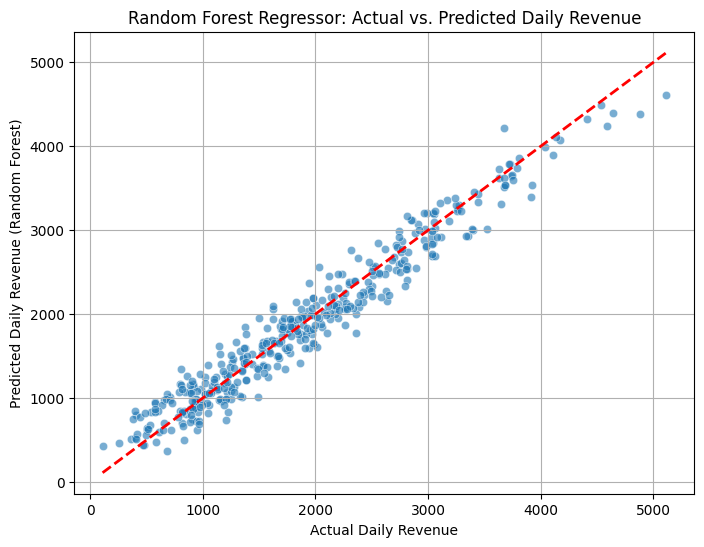

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_scaled, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Daily Revenue")
plt.ylabel("Predicted Daily Revenue (Random Forest)")
plt.title("Random Forest Regressor: Actual vs. Predicted Daily Revenue")
plt.grid(True)
plt.show()

#Support Vector Regressor

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model with scaled data
# SVR can be sensitive to scaling, which we have already done.
# You might want to tune parameters like kernel, C, epsilon, gamma for optimal performance.
svr_model_scaled = SVR(kernel='rbf', C=1.0, epsilon=0.1) # Common starting parameters
svr_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svr_scaled = svr_model_scaled.predict(X_test_scaled)

# Evaluate the SVR model
mse_svr_scaled = mean_squared_error(y_test, y_pred_svr_scaled)
rmse_svr_scaled = np.sqrt(mse_svr_scaled)
r2_svr_scaled = r2_score(y_test, y_pred_svr_scaled)

print(f"Scaled Support Vector Regressor Mean Squared Error (MSE): {mse_svr_scaled:.2f}")
print(f"Scaled Support Vector Regressor Root Mean Squared Error (RMSE): {rmse_svr_scaled:.2f}")
print(f"Scaled Support Vector Regressor R-squared (R2): {r2_svr_scaled:.2f}")

Scaled Support Vector Regressor Mean Squared Error (MSE): 833421.74
Scaled Support Vector Regressor Root Mean Squared Error (RMSE): 912.92
Scaled Support Vector Regressor R-squared (R2): 0.11


* Compared to the Linear Regression, Lasso, Ridge, and especially the Random Forest Regressor, the SVR model, with its current parameters (kernel='rbf', C=1.0, epsilon=0.1), shows significantly worse performance with a very low R-squared value (0.11).
* This indicates that this particular SVR configuration explains only a small portion of the variance in Daily_Revenue and is not performing well on this dataset.

### Predicted vs. Actual Values for Support Vector Regressor (SVR)

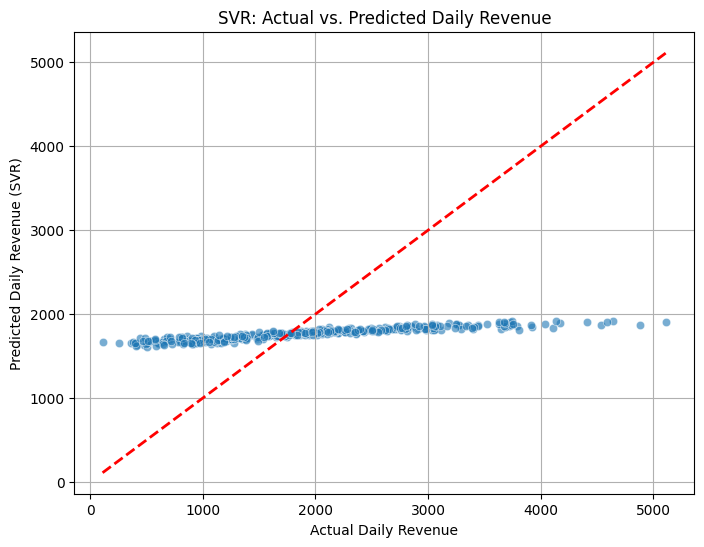

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_svr_scaled, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Daily Revenue")
plt.ylabel("Predicted Daily Revenue (SVR)")
plt.title("SVR: Actual vs. Predicted Daily Revenue")
plt.grid(True)
plt.show()

### Hyperparameter Tuning SVR using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVR tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best SVR Parameters: {best_params}")
print(f"Best SVR R-squared from Grid Search (on training data): {best_score:.2f}")

# Train SVR with best parameters
best_svr_model = SVR(kernel='rbf', **best_params)
best_svr_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set using the best SVR model
y_pred_best_svr = best_svr_model.predict(X_test_scaled)

# Evaluate the best SVR model on the test set
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
rmse_best_svr = np.sqrt(mse_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)

print(f"\nTunned SVR Mean Squared Error (MSE) on Test Set: {mse_best_svr:.2f}")
print(f"Tunned SVR Root Mean Squared Error (RMSE) on Test Set: {rmse_best_svr:.2f}")
print(f"Tunned SVR R-squared (R2) on Test Set: {r2_best_svr:.2f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best SVR Parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 0.1}
Best SVR R-squared from Grid Search (on training data): 0.93

Tunned SVR Mean Squared Error (MSE) on Test Set: 56167.33
Tunned SVR Root Mean Squared Error (RMSE) on Test Set: 237.00
Tunned SVR R-squared (R2) on Test Set: 0.94


* Best Parameters Found: The GridSearchCV identified {'C': 100, 'epsilon': 0.01, 'gamma': 0.1} as the optimal parameters for the SVR model.

* Significant Performance Improvement: With these tuned parameters, the SVR model's performance on the test set has dramatically improved:
* R-squared (R2): Increased from a very low 0.11 to 0.94.
* Root Mean Squared Error (RMSE): Decreased from 912.92 to 237.00.

## XGBoost Regressor with Scaled Data

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model with scaled data
# You might want to tune parameters like n_estimators, learning_rate, max_depth, etc.
xgb_model_scaled = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_xgb_scaled = xgb_model_scaled.predict(X_test_scaled)

# Evaluate the XGBoost model
mse_xgb_scaled = mean_squared_error(y_test, y_pred_xgb_scaled)
rmse_xgb_scaled = np.sqrt(mse_xgb_scaled)
r2_xgb_scaled = r2_score(y_test, y_pred_xgb_scaled)

print(f"Scaled XGBoost Regressor Mean Squared Error (MSE): {mse_xgb_scaled:.2f}")
print(f"Scaled XGBoost Regressor Root Mean Squared Error (RMSE): {rmse_xgb_scaled:.2f}")
print(f"Scaled XGBoost Regressor R-squared (R2): {r2_xgb_scaled:.2f}")

Scaled XGBoost Regressor Mean Squared Error (MSE): 48165.13
Scaled XGBoost Regressor Root Mean Squared Error (RMSE): 219.47
Scaled XGBoost Regressor R-squared (R2): 0.95


### Predicted vs. Actual Values for XGBoost Regressor

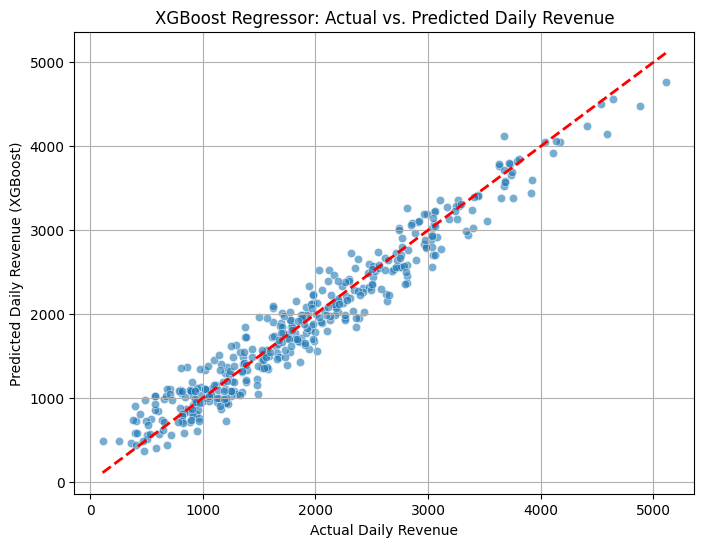

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb_scaled, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Daily Revenue")
plt.ylabel("Predicted Daily Revenue (XGBoost)")
plt.title("XGBoost Regressor: Actual vs. Predicted Daily Revenue")
plt.grid(True)
plt.show()

#KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize and train the KNN Regressor model with scaled data
# You might want to tune the 'n_neighbors' parameter
knn_model_scaled = KNeighborsRegressor(n_neighbors=5) # Using default n_neighbors=5
knn_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn_scaled = knn_model_scaled.predict(X_test_scaled)

# Evaluate the KNN model
mse_knn_scaled = mean_squared_error(y_test, y_pred_knn_scaled)
rmse_knn_scaled = np.sqrt(mse_knn_scaled)
r2_knn_scaled = r2_score(y_test, y_pred_knn_scaled)

print(f"Scaled K-Nearest Neighbors Regressor Mean Squared Error (MSE): {mse_knn_scaled:.2f}")
print(f"Scaled K-Nearest Neighbors Regressor Root Mean Squared Error (RMSE): {rmse_knn_scaled:.2f}")
print(f"Scaled K-Nearest Neighbors Regressor R-squared (R2): {r2_knn_scaled:.2f}")

Scaled K-Nearest Neighbors Regressor Mean Squared Error (MSE): 89234.58
Scaled K-Nearest Neighbors Regressor Root Mean Squared Error (RMSE): 298.72
Scaled K-Nearest Neighbors Regressor R-squared (R2): 0.90


## Final Model Performance Comparison

Let's compare the performance metrics of all the regression models we've trained, including the hyperparameter-tuned SVR model, to determine the best performer for predicting 'Daily_Revenue'.

In [ ]:
import pandas as pd

# Create a dictionary to store model performance
performance_data = {
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression',
              'Random Forest Regressor', 'SVR (Default)', 'SVR (Tuned)', 'XGBoost Regressor', 'KNN Regressor'],
    'R-squared': [r2, r2_lasso, r2_ridge, r2_rf_scaled, r2_svr_scaled, r2_best_svr, r2_xgb_scaled, r2_knn_scaled],
    'MSE': [mse, mse_lasso, mse_ridge, mse_rf_scaled, mse_svr_scaled, mse_best_svr, mse_xgb_scaled, mse_knn_scaled],
    'RMSE': [rmse, rmse_lasso, rmse_ridge, rmse_rf_scaled, rmse_svr_scaled, rmse_best_svr, rmse_xgb_scaled, rmse_knn_scaled]
}

# Create a DataFrame for better presentation
performance_df = pd.DataFrame(performance_data)

# Sort by R-squared in descending order
performance_df = performance_df.sort_values(by='R-squared', ascending=False).reset_index(drop=True)

display(performance_df.round(2))

,Model,R-squared,MSE,RMSE
0,Random Forest Regressor,0.95,47670.69,218.34
1,XGBoost Regressor,0.95,48165.13,219.47
2,SVR (Tuned),0.94,56167.33,237.00
3,KNN Regressor,0.90,89234.58,298.72
4,Ridge Regression,0.90,97566.72,312.36
5,Lasso Regression,0.90,97567.83,312.36
6,Linear Regression,0.90,97569.72,312.36
7,SVR (Default),0.11,833421.74,912.92


## Best Model Selection

Based on the performance metrics:

*   **Random Forest Regressor** and **XGBoost Regressor** are the top-performing models, both achieving an R-squared of **0.95**. They also exhibit the lowest Mean Squared Error (MSE) and Root Mean Squared Error (RMSE), indicating highly accurate predictions with minimal error.

*   The **SVR (Tuned)** model showed a remarkable improvement after hyperparameter tuning, jumping from a very poor R-squared of 0.11 to a competitive **0.94**, which is close to the tree-based models.

*   **Linear Regression**, **Lasso Regression**, and **Ridge Regression** all performed similarly with an R-squared of **0.90**. While decent, they are outperformed by the ensemble and tuned SVR models.

**Conclusion:**

For this dataset, both the **Random Forest Regressor** and **XGBoost Regressor** are excellent choices for predicting daily revenue, as they demonstrate the highest predictive accuracy. Given their similar performance, the choice between them might come down to factors like interpretability (Random Forest can offer feature importances more straightforwardly) or computational efficiency for very large datasets (XGBoost can sometimes be faster). The **tuned SVR** is also a strong contender and demonstrates the value of hyperparameter optimization.

* The XGBoost model performs very well, achieving an R-squared value of 0.95, which is similar to the Random Forest Regressor. Both models significantly outperform the simple Linear Regression, Lasso, Ridge, and especially the Support Vector Regressor (SVR) on this dataset, indicating that tree-based ensemble methods are very effective for this prediction task.